# **🏛️ Global Budget Allocation: Multi-Output Fiscal Forecasting Engine**
The Global Government Budget Dataset (1936–2026) is a comprehensive historical collection of government budget allocations for 45 major economies spanning nearly nine decades. Together, these countries contribute approximately 85–90% of global GDP, making this dataset an excellent resource for macroeconomic analysis, public finance research, machine learning, and forecasting.

The dataset combines officially available macroeconomic indicators with statistically interpolated historical estimates to create a continuous, structured time series with minimal missing values. All monetary figures are standardized to Billions of U.S. Dollars (USD), enabling meaningful comparisons across countries and years.

## **Dataset Overview**
| Feature | Description |
| :--- | :--- |
| **Country** | The name of the nation or sovereign territory (45 countries represented) |
| **Year** | The fiscal calendar year of the recorded budget (1936–2026) |
| **Total_Budget_Billions_USD** | Total government consolidated budget size scaled in Billions of USD |
| **Defense_Percentage** | Percentage of the total national budget allocated to military and defense forces |
| **Education_Percentage** | Percentage of the total national budget allocated to public and higher education systems |
| **Health_Percentage** | Percentage of the total national budget allocated to healthcare services and infrastructure |
| **Interest_Payments_Percentage** | Percentage of the total national budget allocated to servicing national debt obligations |
| **Infrastructure_Percentage** | Percentage of the total national budget allocated to public works, transport, and utilities |
| **Agriculture_Percentage** | Percentage of the total national budget allocated to agricultural development and food security |
| **State_Transfers_Percentage** | Percentage of the total national budget allocated to regional, state, or municipal subsidies |
| **Social_Welfare_Percentage** | Percentage of the total national budget allocated to social safety nets and public assistance |
| **Administration_Percentage** | Percentage of the total national budget allocated to civil service and government operations |
| **Defense_Amount_Billions_USD** | Calculated absolute spending on military and defense sectors in Billions of USD |
| **Education_Amount_Billions_USD** | Calculated absolute spending on public and higher education in Billions of USD |
| **Health_Amount_Billions_USD** | Calculated absolute spending on healthcare and medical infrastructure in Billions of USD |
| **Interest_Payments_Amount_Billions_USD** | Calculated absolute spending on national debt interest obligations in Billions of USD |
| **Infrastructure_Amount_Billions_USD** | Calculated absolute spending on public works and utilities in Billions of USD |
| **Agriculture_Amount_Billions_USD** | Calculated absolute spending on domestic agriculture and food security in Billions of USD |
| **State_Transfers_Amount_Billions_USD** | Calculated absolute spending on localized state and regional allocations in Billions of USD |
| **Social_Welfare_Amount_Billions_USD** | Calculated absolute spending on social safety nets and welfare programs in Billions of USD |
| **Administration_Amount_Billions_USD** | Calculated absolute spending on administrative overhead and civil services in Billions of USD |


## **Machine Learning Applications**

#### **1. Unsupervised Anomaly Detection: *The Policy Shift Visualizer***

Instead of just asking *what* a country spends, use unsupervised learning to automatically catch *when* a country radically deviates from its typical fiscal footprint.

* **The ML Concept:** Isolation Forests or One-Class SVMs.
* **How it works:** Fit the model on multi-dimensional allocation vectors (e.g., the ratio of Defense to Education to Infrastructure). The anomalies flagged by the model will naturally map to major macro events — catching wars, fiscal collapses, or massive post-pandemic stimulus regimes without you having to label them manually.

#### **2. Advanced Multi-Output Time Series: *The Fiscal Forecasting Engine***

Predicting future budgets is tough because spending categories compete inside a zero-sum game: if Defense goes up, another sector usually has to give. Standard individual regressions will ignore this constraint.

* **The ML Concept:** Multi-output Vector Autoregression (VAR) or Deep Learning architectures like a Sequence-to-Sequence LSTM / Temporal Fusion Transformer.
* **How it works:** Treat the spending categories as a combined vector. By forecasting them simultaneously, your model learns to respect the implicit budget constraints, identifying how a sudden macroeconomic spike in national debt affects long-term healthcare infrastructure.

#### **3. Macro Feature Engineering & Supervised Tree-Based Pipelines**

If your goal is to predict either a future allocation bracket or a macroeconomic outcome (like predicting if a specific budget strategy correlates with a future recession or GDP boost):

* **The ML Concept:** Gradient Boosted Decision Trees via LightGBM or XGBoost.
* **How it works:** You can engineer dynamic historical features like rolling windows of fiscal momentum, trailing 3-year volatility of education spending, or relative allocation ratios against regional neighbors. Tree-based architectures handle these varying country scales exceptionally well compared to linear models.

---

### **Notebook Structure**
* **Section 1: The Data Tapestry (EDA):** Spend time creating beautiful, interactive subplot grids tracking how the global median spending vector shifted from the post-WWII era, through the Cold War, into the tech boom, and leading up to 2026.
* **Section 2: The Macro Synthesis (Feature Engineering):** Show your process for cleanly aligning external indicators without running into lookahead bias or data leakage.
* **Section 3: The Discovery Phase (Unsupervised Learning):** Run your anomaly detection pipeline. Use an interactive visualization to plot the anomaly scores across a timeline, proving that the model successfully identified historical pivot points entirely on its own.
* **Section 4: The Predictive Sandbox (Modeling):** Train your forecasting or tree-based models. Include a robust cross-validation scheme that splits data by *time* (e.g., training on 1936–2015, testing on 2016–2026) to mimic a real-world deployed scenario.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import time
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
from matplotlib import pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ashyou09/global-budget-allocation-dataset-19362026/Master_Global_Budgets_Historical.csv
/kaggle/input/datasets/ashyou09/global-budget-allocation-dataset-19362026/individual_countries/individual_countries/Sweden_Real_Budget_1946_2026.csv
/kaggle/input/datasets/ashyou09/global-budget-allocation-dataset-19362026/individual_countries/individual_countries/United_Arab_Emirates_Real_Budget_1946_2026.csv
/kaggle/input/datasets/ashyou09/global-budget-allocation-dataset-19362026/individual_countries/individual_countries/Indonesia_Real_Budget_1946_2026.csv
/kaggle/input/datasets/ashyou09/global-budget-allocation-dataset-19362026/individual_countries/individual_countries/Colombia_Real_Budget_1946_2026.csv
/kaggle/input/datasets/ashyou09/global-budget-allocation-dataset-19362026/individual_countries/individual_countries/Greece_Real_Budget_1946_2026.csv
/kaggle/input/datasets/ashyou09/global-budget-allocation-dataset-19362026/individual_countries/individual_countries/Spain_Rea

In [2]:
data = pd.read_csv('/kaggle/input/datasets/ashyou09/global-budget-allocation-dataset-19362026/Master_Global_Budgets_Historical.csv')
data.shape

(3654, 21)

In [3]:
data.isnull().sum()

Country                                          0
Year                                             0
Defense_Percentage                               0
Education_Percentage                             0
Health_Percentage                                0
Interest_Payments_Percentage                     0
Total_Budget_Billions_USD                        0
Infrastructure_Percentage                        0
Agriculture_Percentage                           0
State_Transfers_Percentage                       0
Social_Welfare_Percentage                        0
Administration_and_Others_Percentage             0
Defense_Amount_Billions_USD                      0
Education_Amount_Billions_USD                    0
Health_Amount_Billions_USD                       0
Interest_Payments_Amount_Billions_USD            0
Infrastructure_Amount_Billions_USD               0
Agriculture_Amount_Billions_USD                  0
State_Transfers_Amount_Billions_USD              0
Social_Welfare_Amount_Billions_

# **Exploratory Data Analysis**
* Check for row-wise structural coherence by summing all percentage allocation values to ensure they consistently equal 100% or to identify tracking drift.
* Plot multi-sector stacked area charts over the 1936 to 2026 timeline to track global structural priority shifts across decades.
* Compute year-over-year percentage variances for individual categories like defense or healthcare to highlight high-volatility historical fiscal regimes.
* Apply log-scale transformations on total budget distributions to inspect the massive scale disparities among the 45 represented nations.
* Build a cross-sector correlation matrix to identify structural tradeoffs, highlighting which spending pillars shrink when others expand.
* Evaluate chronological gaps within individual country timelines to map out missing historical data patches before launching time-series models.
* Use rolling Z-scores across spending metrics to isolate statistical spending outliers that match major geopolitical or macroeconomic disruptions.

In [4]:
data['Country'].value_counts()

Country
USA                     91
UK                      91
Bangladesh              81
Australia               81
Argentina               81
Chile                   81
Colombia                81
Egypt                   81
France                  81
Greece                  81
Indonesia               81
Brazil                  81
Canada                  81
Turkey                  81
Poland                  81
Portugal                81
Iran                    81
Italy                   81
Kazakhstan              81
Ireland                 81
Israel                  81
Pakistan                81
Netherlands             81
New Zealand             81
Nigeria                 81
Philippines             81
Peru                    81
Malaysia                81
Mexico                  81
United Arab Emirates    81
Spain                   81
Sweden                  81
Romania                 81
Singapore               81
South Africa            81
Russia                  81
Saudi Arabia        

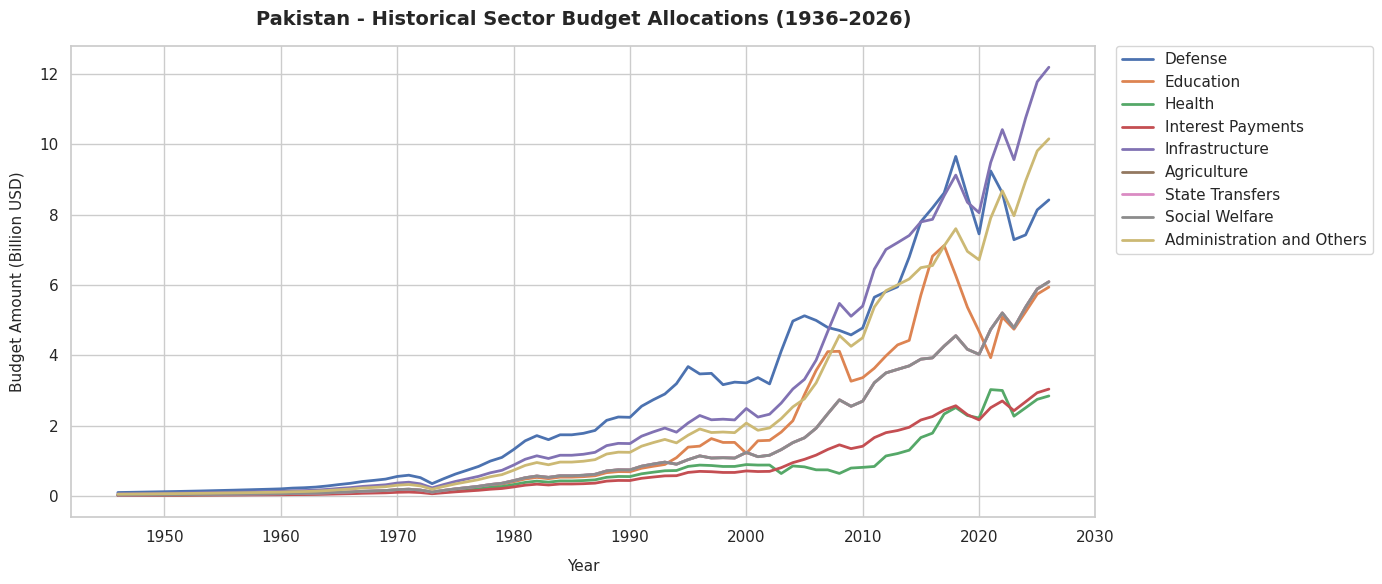

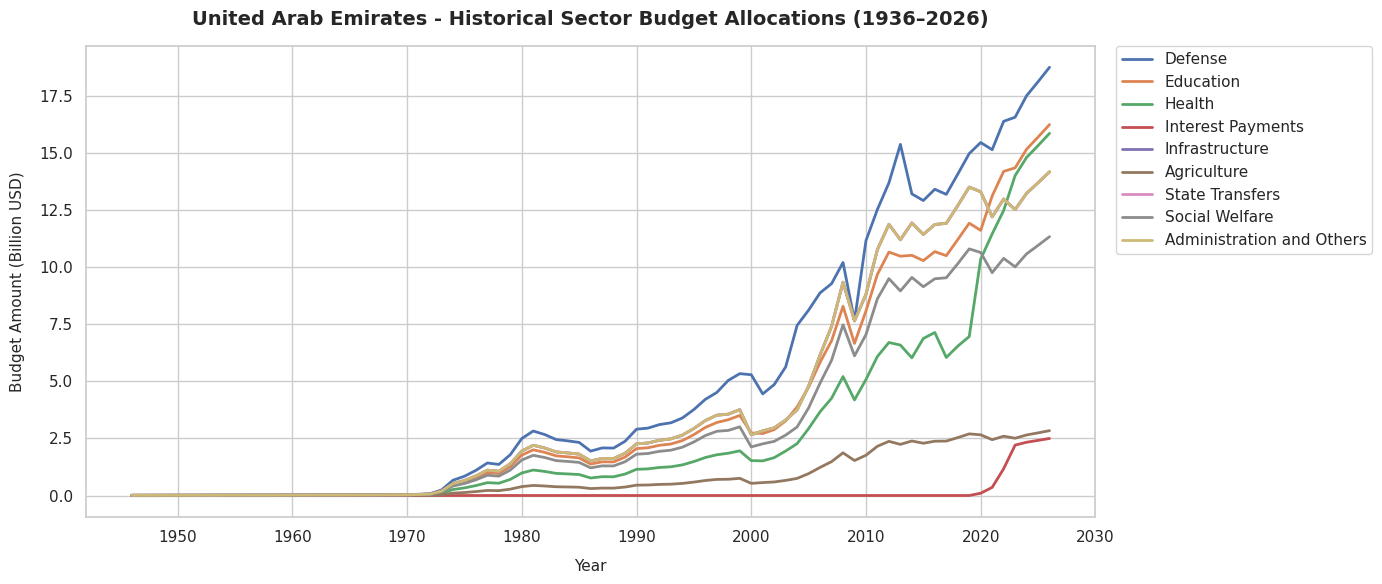

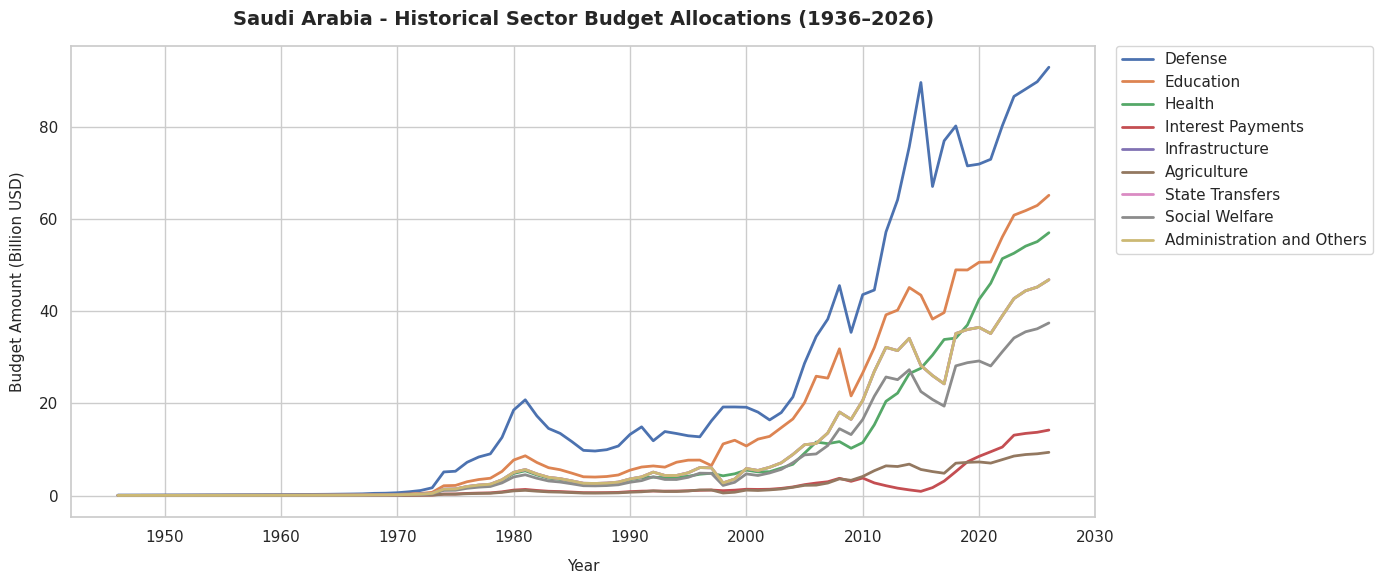

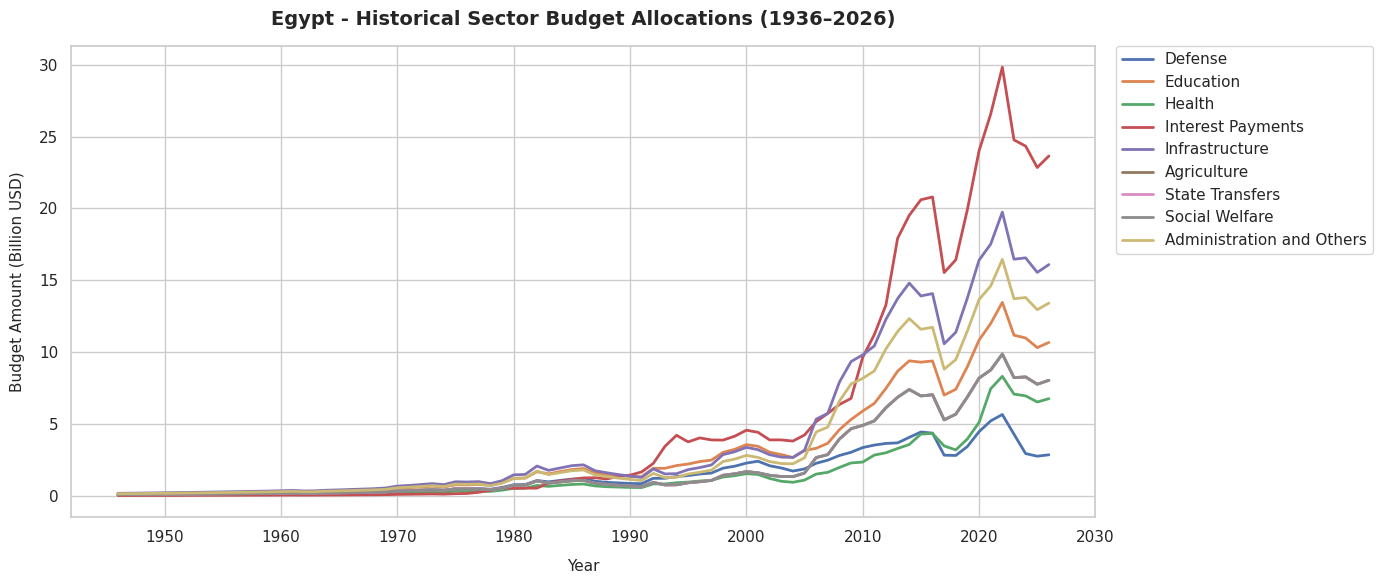

In [5]:
amount_cols = [
    'Defense_Amount_Billions_USD',
    'Education_Amount_Billions_USD',
    'Health_Amount_Billions_USD',
    'Interest_Payments_Amount_Billions_USD',
    'Infrastructure_Amount_Billions_USD',
    'Agriculture_Amount_Billions_USD',
    'State_Transfers_Amount_Billions_USD',
    'Social_Welfare_Amount_Billions_USD',
    'Administration_and_Others_Amount_Billions_USD'
]

unique_countries = ['Pakistan', 'United Arab Emirates', 'Saudi Arabia', 'Egypt']


for country in unique_countries:
    country_df = data[data['Country'] == country].sort_values('Year')
    
    plt.figure(figsize=(14, 6))
    
    for col in amount_cols:
        label_name = col.replace('_Amount_Billions_USD', '').replace('_', ' ')
        sns.lineplot(
            data=country_df, 
            x='Year', 
            y=col, 
            label=label_name, 
            linewidth=2
        )
        
    plt.title(f'{country} - Historical Sector Budget Allocations (1936–2026)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Year', fontsize=11, labelpad=10)
    plt.ylabel('Budget Amount (Billion USD)', fontsize=11, labelpad=10)
    
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, frameon=True)
    plt.tight_layout()
    plt.show()

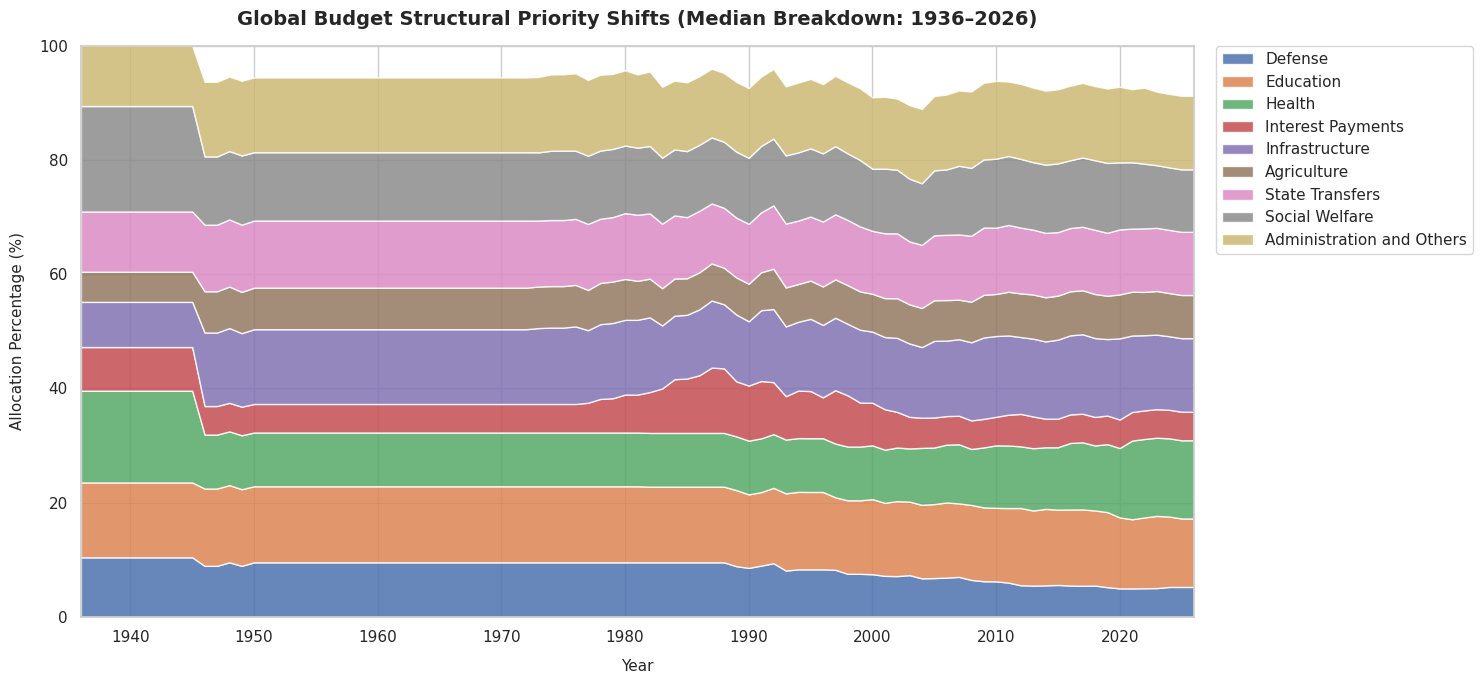

In [6]:
percentage_cols = [
    'Defense_Percentage',
    'Education_Percentage',
    'Health_Percentage',
    'Interest_Payments_Percentage',
    'Infrastructure_Percentage',
    'Agriculture_Percentage',
    'State_Transfers_Percentage',
    'Social_Welfare_Percentage',
    'Administration_and_Others_Percentage'
]

labels = [col.replace('_Percentage', '').replace('_', ' ') for col in percentage_cols]

# Aggregate the global median trend per year to capture structural shifts cleanly
global_trends = data.groupby('Year')[percentage_cols].median().reset_index()
plt.figure(figsize=(15, 7))

# Plot the stacked area chart
plt.stackplot(
    global_trends['Year'], 
    [global_trends[col] for col in percentage_cols], 
    labels=labels,
    alpha=0.85,
    colors=sns.color_palette("deep", n_colors=9)
)

plt.title('Global Budget Structural Priority Shifts (Median Breakdown: 1936–2026)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=11, labelpad=10)
plt.ylabel('Allocation Percentage (%)', fontsize=11, labelpad=10)
plt.xlim(1936, 2026)
plt.ylim(0, 100)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, frameon=True)
plt.tight_layout()
plt.show()

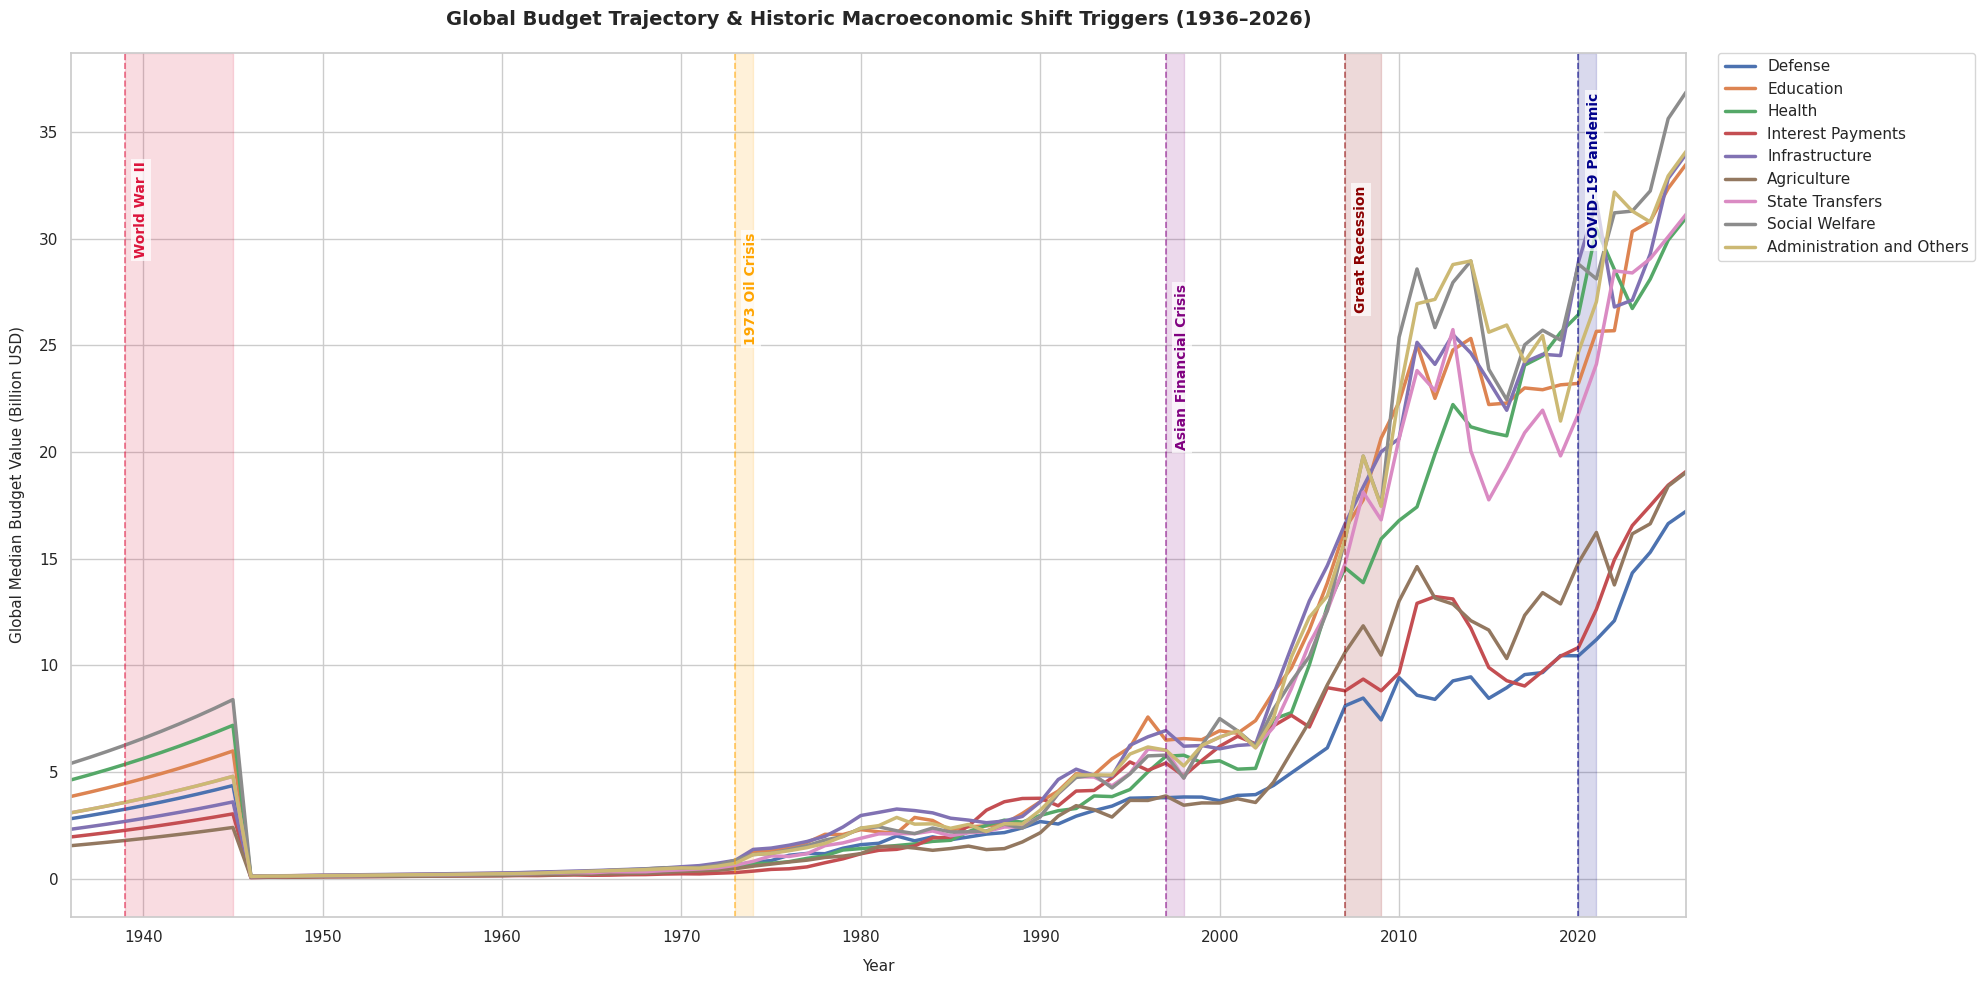

In [7]:
amount_cols = [
    'Defense_Amount_Billions_USD',
    'Education_Amount_Billions_USD',
    'Health_Amount_Billions_USD',
    'Interest_Payments_Amount_Billions_USD',
    'Infrastructure_Amount_Billions_USD',
    'Agriculture_Amount_Billions_USD',
    'State_Transfers_Amount_Billions_USD',
    'Social_Welfare_Amount_Billions_USD',
    'Administration_and_Others_Amount_Billions_USD'
]

global_yearly = data.groupby('Year')[amount_cols].median().reset_index()

# Define major global historical events for context mapping
global_events = [
    (1939, 1945, "World War II", "crimson", 0.85),
    (1973, 1974, "1973 Oil Crisis", "orange", 0.75),
    (1997, 1998, "Asian Financial Crisis", "purple", 0.65),
    (2007, 2009, "Great Recession", "darkred", 0.80),
    (2020, 2021, "COVID-19 Pandemic", "darkblue", 0.90)
]

fig, ax = plt.subplots(figsize=(20, 10))


for col in amount_cols:
    label_name = col.replace('_Amount_Billions_USD', '').replace('_', ' ')
    sns.lineplot(
        data=global_yearly, 
        x='Year', 
        y=col, 
        label=label_name, 
        linewidth=2.5,
        ax=ax
    )

y_max = global_yearly[amount_cols].max().max() # Find the max valuation to anchor label positions

for start_yr, end_yr, label, color, y_ratio in global_events:
    # Shade the span of the event
    ax.axvspan(start_yr, end_yr, color=color, alpha=0.15)
    
    # Add a dashed indicator line at the start of the event
    ax.axvline(x=start_yr, color=color, linestyle="--", alpha=0.6, linewidth=1.2)
    
    ax.text(
        x=start_yr + 0.5, 
        y=y_max * y_ratio, 
        s=label, 
        color=color, 
        weight='bold', 
        fontsize=10, 
        rotation=90,
        va='center',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2)
    )

ax.set_title('Global Budget Trajectory & Historic Macroeconomic Shift Triggers (1936–2026)', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=11, labelpad=10)
ax.set_ylabel('Global Median Budget Value (Billion USD)', fontsize=11, labelpad=10)
ax.set_xlim(1936, 2026)

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, frameon=True)
plt.tight_layout()
plt.show()

# **ML Application**

Series is non-stationary. Applying first-difference...
Optimal lag order selected: 5
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 19, Jul, 2026
Time:                     08:22:05
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                   -7.33661
Nobs:                     75.0000    HQIC:                  -9.74966
Log likelihood:           23.6578    FPE:                1.36229e-05
AIC:                     -11.3536    Det(Omega_mle):     3.07588e-06
--------------------------------------------------------------------
Results for equation Defense_Percentage
                                  coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------------------
const                               -0.074251         0.039621           -1.874           0.06

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


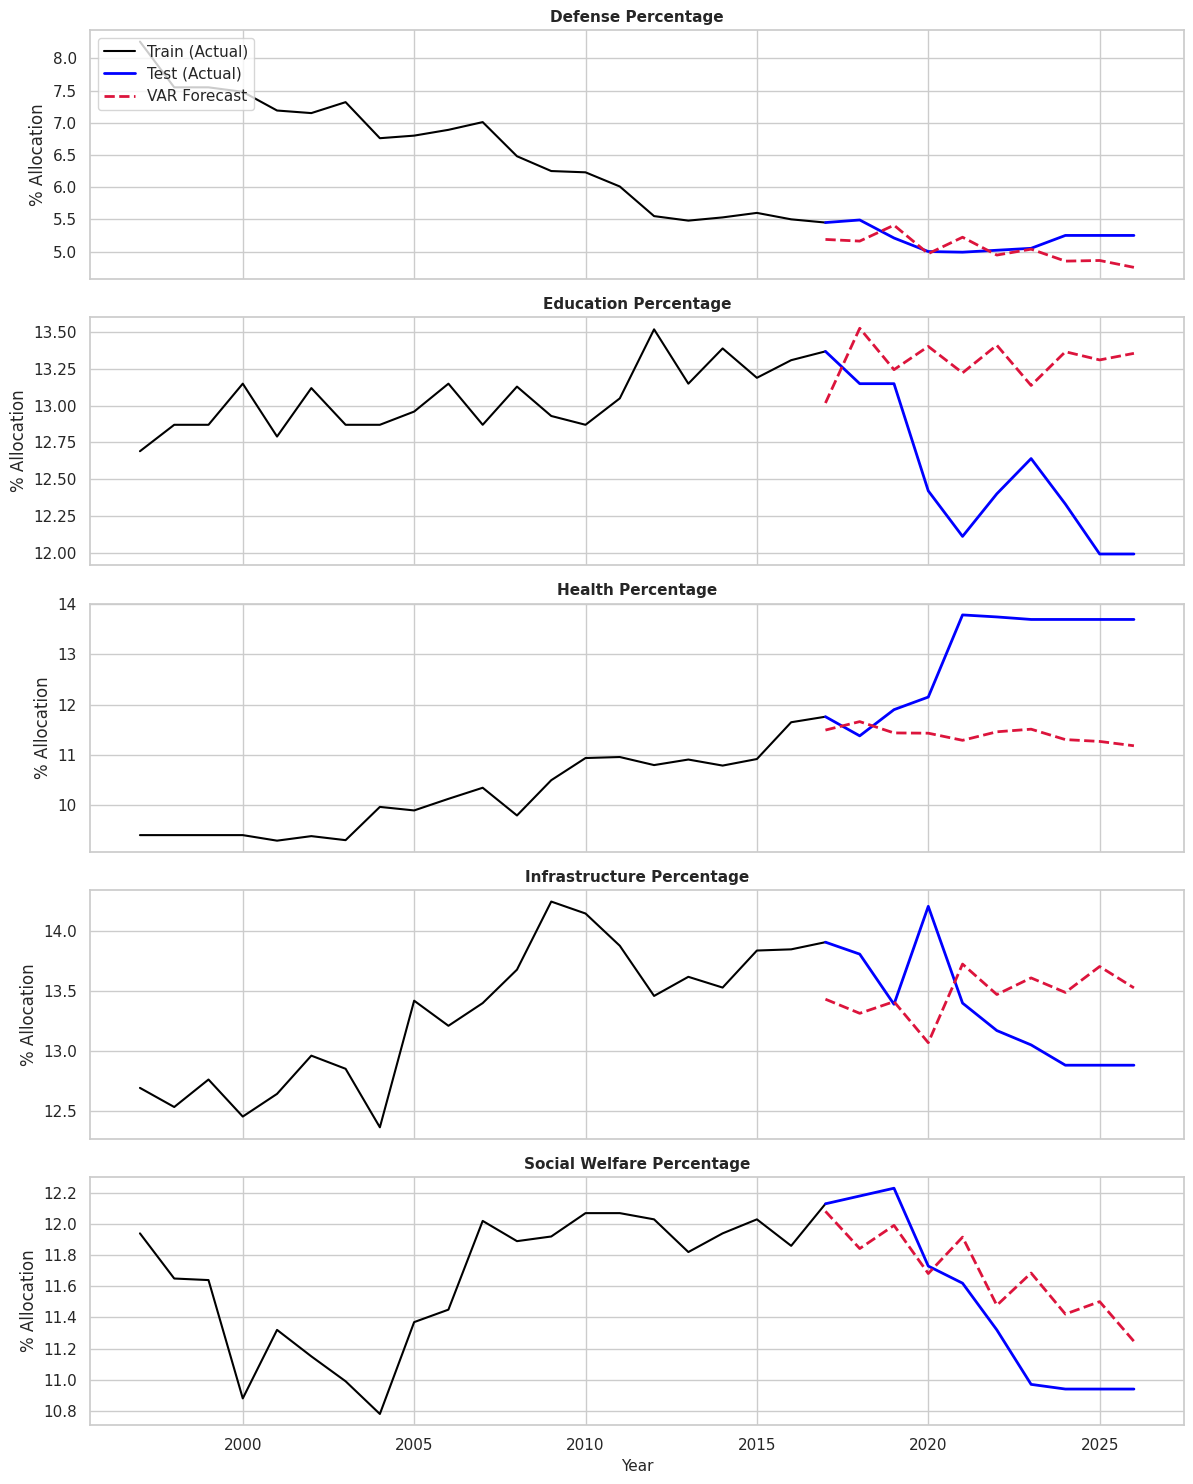

In [8]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

# 1. Define the targets (percentage allocations represent the zero-sum nature best)
target_cols = [
    'Defense_Percentage',
    'Education_Percentage',
    'Health_Percentage',
    'Infrastructure_Percentage',
    'Social_Welfare_Percentage'
]

# 2. Prepare the time-series dataframe (Aggregated global median by year)
ts_data = data.groupby('Year')[target_cols].median()

# 3. Stationarity Check (ADF Test) & Differencing if necessary
# VAR models require stationary inputs. If p-value > 0.05, we difference the series.
is_stationary = True
for col in target_cols:
    p_val = adfuller(ts_data[col])[1]
    if p_val > 0.05:
        is_stationary = False

if not is_stationary:
    print("Series is non-stationary. Applying first-difference...")
    ts_data_transformed = ts_data.diff().dropna()
else:
    print("Series is stationary. Proceeding with raw values...")
    ts_data_transformed = ts_data.copy()

# 4. Train-Test Split (Hold out the last 10 years for validation, e.g., 2017–2026)
test_periods = 10
train_data = ts_data_transformed.iloc[:-test_periods]
test_data = ts_data_transformed.iloc[-test_periods:]

# 5. Initialize and Fit the VAR Model
model = VAR(train_data)

# Select optimal lag order automatically based on Akaike Information Criterion (AIC)
optimal_lag = model.select_order(maxlags=5).selected_orders['aic']
print(f"Optimal lag order selected: {optimal_lag}")

model_fitted = model.fit(optimal_lag)
print(model_fitted.summary())

# 6. Forecasting Multi-Steps Ahead
lag_order = model_fitted.k_ar
forecast_input = train_data.values[-lag_order:]
forecast_diff = model_fitted.forecast(y=forecast_input, steps=test_periods)

# Convert forecast array back into a DataFrame
forecast_diff_df = pd.DataFrame(forecast_diff, index=ts_data.index[-test_periods:], columns=target_cols)

# 7. Invert Differencing (if differencing was performed) to get back to original percentages
if not is_stationary:
    forecast_final = forecast_diff_df.copy()
    columns = forecast_final.columns
    for col in columns:
        # Reconstruct cumulative values using the last raw training observation as baseline
        baseline = ts_data[col].iloc[-(test_periods + 1)]
        forecast_final[col] = baseline + forecast_final[col].cumsum()
else:
    forecast_final = forecast_diff_df

# 8. Visualize the Actual vs. Predicted Multi-Output Matrix
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=len(target_cols), ncols=1, figsize=(12, 3 * len(target_cols)), sharex=True)

for i, col in enumerate(target_cols):
    ax = axes[i]
    
    # Plot historical training data (last 20 years for context window clarity)
    ax.plot(ts_data.index[-30:-test_periods+1], ts_data[col].iloc[-30:-test_periods+1], label='Train (Actual)', color='black', linewidth=1.5)
    
    # Plot actual held-out test target data
    ax.plot(ts_data.index[-test_periods:], ts_data[col].iloc[-test_periods:], label='Test (Actual)', color='blue', linewidth=2)
    
    # Plot simultaneous VAR forecast prediction paths
    ax.plot(forecast_final.index, forecast_final[col], label='VAR Forecast', color='crimson', linestyle='--', linewidth=2)
    
    ax.set_title(col.replace('_', ' '), fontsize=11, fontweight='bold')
    if i == 0:
        ax.legend(loc='upper left')
    ax.set_ylabel('% Allocation')

plt.xlabel('Year', fontsize=11)
plt.tight_layout()
plt.show()